# LAB 03: FEATURE DETECTION AND IMAGE MATCHING


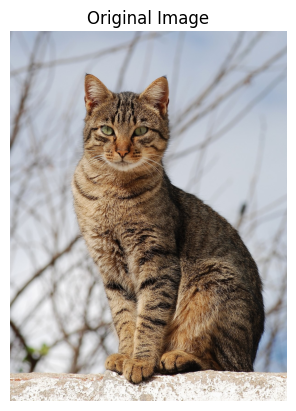

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as An

from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift

img = cv2.imread('cat.jpg')
img2 = cv2.imread('dog.jpg')

def show_img(image, title='Image', cmap=None):
    if image is None: return
    if len(image.shape) == 3 and cmap is None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        An.imshow(image)
    else:
        An.imshow(image, cmap=cmap if cmap else 'gray')
    An.title(title)
    An.axis('off')
    An.show()

if img is not None:
    show_img(img, "Original Image")

## 1. Fast Fourier Transform (FFT) algorithm để phát hiện ảnh mờ

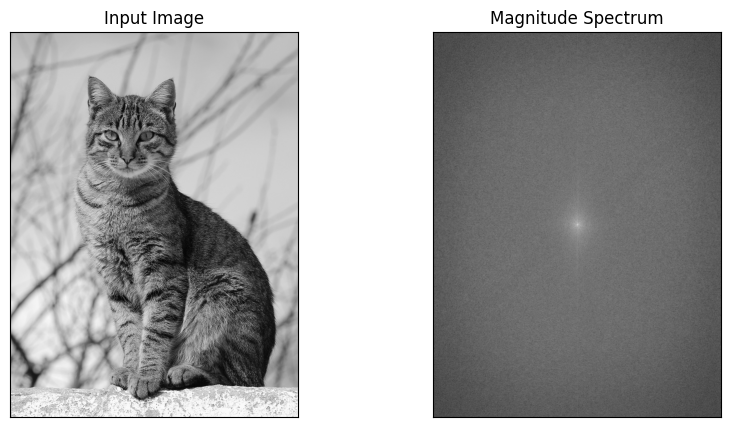

In [2]:
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_float32 = np.float32(gray)
    dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))
    An.figure(figsize=(10, 5))
    An.subplot(121), An.imshow(gray, cmap='gray')
    An.title('Input Image'), An.xticks([]), An.yticks([])
    An.subplot(122), An.imshow(magnitude_spectrum, cmap='gray')
    An.title('Magnitude Spectrum'), An.xticks([]), An.yticks([])
    An.show()

## 2. Band-pass filtering by Difference of Gaussians với Thư viện ảnh mẫu skimage

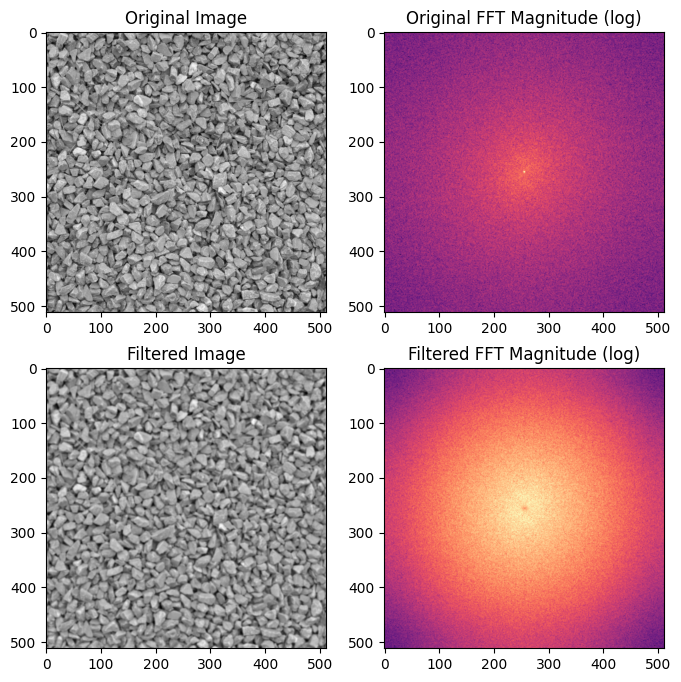

In [3]:
image = gravel()
wimage = image * window('hann', image.shape)
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * window('hann', image.shape)
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))
fig, ax = An.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')
An.show()

## 3. Thực hành Harris Corner Detection

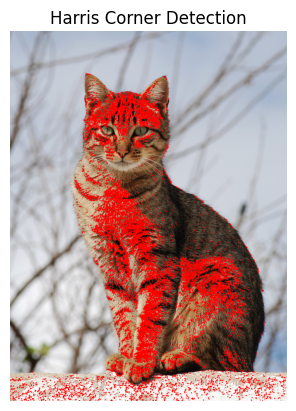

In [4]:
if img is not None:
    copy_img = img.copy()
    gray = cv2.cvtColor(copy_img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    dst = cv2.cornerHarris(gray, 2, 3, 0.04)
    dst = cv2.dilate(dst, None)
    copy_img[dst > 0.01 * dst.max()] = [0, 0, 255]
    cv2.imwrite('example_harris.jpg', copy_img)
    show_img(copy_img, "Harris Corner Detection")